<a href="https://colab.research.google.com/github/Aswath701/EduEnhance/blob/main/Classification_of_Bioprocess_Conditions_using_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load dataset
df = pd.read_csv("bioprocess_classification_data_300.csv")

In [3]:
df.head()

,Time,Biomass,Substrate,Product,Phase
0,0.922338,0.035073,18.354021,0.004435,Lag
1,0.801590,0.051470,18.412667,0.018213,Lag
2,1.758543,0.072136,18.078624,0.039971,Lag
3,2.069751,0.017358,19.747157,0.046044,Lag
4,0.652695,0.034919,19.612403,0.037413,Lag


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time       300 non-null    float64
 1   Biomass    300 non-null    float64
 2   Substrate  300 non-null    float64
 3   Product    300 non-null    float64
 4   Phase      300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB


In [5]:
# Summary statistics
print("\n🔹 Statistical Summary:")
print(df.describe())


🔹 Statistical Summary:
             Time     Biomass   Substrate     Product
count  300.000000  300.000000  300.000000  300.000000
mean     6.611742    0.649882   12.714995    0.543103
std      4.576283    0.507814    6.115498    0.504606
min      0.532736    0.010417    1.044460    0.003285
25%      2.149745    0.071935    7.187299    0.039919
50%      6.197682    0.647670   14.943025    0.455469
75%     10.446373    1.122548   18.309164    1.012461
max     14.996482    1.487805   19.969682    1.497688


In [6]:
# Check for missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())


🔹 Missing Values:
Time         0
Biomass      0
Substrate    0
Product      0
Phase        0
dtype: int64


In [10]:
# Class distribution
print("\n🔹 Class Distribution:")
print(df['Phase'].value_counts())


🔹 Class Distribution:
Phase
Lag           100
Log           100
Stationary    100
Name: count, dtype: int64


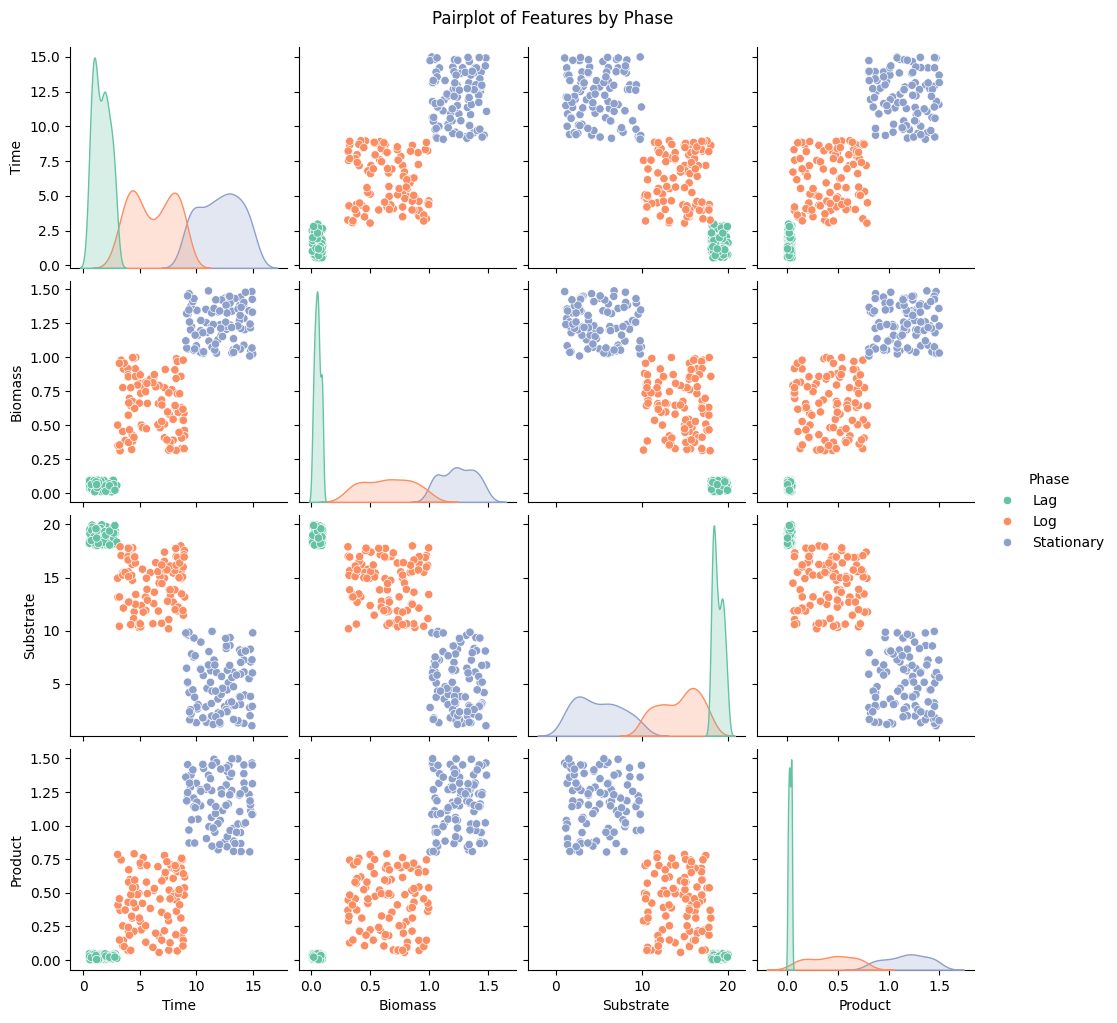

In [8]:
# Pairplot to see relationships between features
sns.pairplot(df, hue="Phase", palette="Set2")
plt.suptitle("Pairplot of Features by Phase", y=1.02)
plt.show()


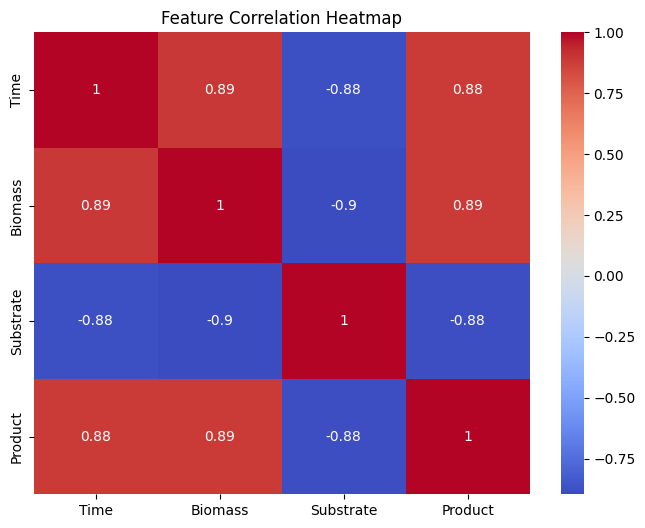

In [9]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop("Phase", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
# Encode target
le = LabelEncoder()
df['Phase_encoded'] = le.fit_transform(df['Phase'])


In [25]:

# Feature & label split
X = df[["Time", "Biomass", "Substrate", "Product"]]
y = df["Phase_encoded"]
target_names = le.classes_



In [26]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





🧪 Model: Decision Tree
Accuracy: 1.0
Confusion Matrix:
 [[22  0  0]
 [ 0 16  0]
 [ 0  0 22]]
Classification Report:
               precision    recall  f1-score   support

         Lag       1.00      1.00      1.00        22
         Log       1.00      1.00      1.00        16
  Stationary       1.00      1.00      1.00        22

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



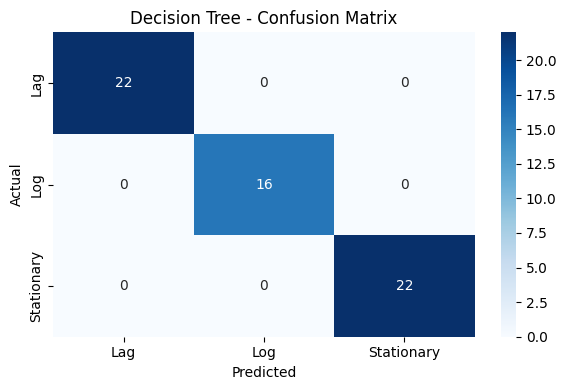


🧪 Model: Random Forest
Accuracy: 1.0
Confusion Matrix:
 [[22  0  0]
 [ 0 16  0]
 [ 0  0 22]]
Classification Report:
               precision    recall  f1-score   support

         Lag       1.00      1.00      1.00        22
         Log       1.00      1.00      1.00        16
  Stationary       1.00      1.00      1.00        22

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



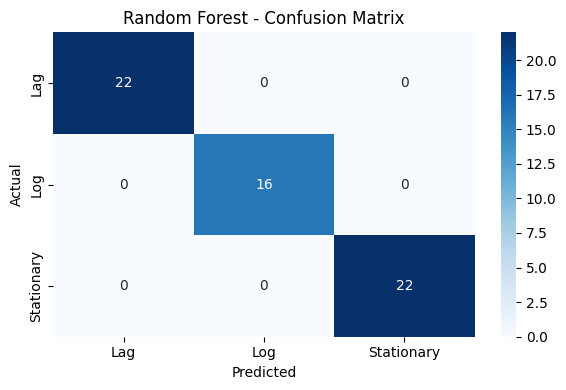


🧪 Model: SVM
Accuracy: 0.9833333333333333
Confusion Matrix:
 [[22  0  0]
 [ 1 15  0]
 [ 0  0 22]]
Classification Report:
               precision    recall  f1-score   support

         Lag       0.96      1.00      0.98        22
         Log       1.00      0.94      0.97        16
  Stationary       1.00      1.00      1.00        22

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



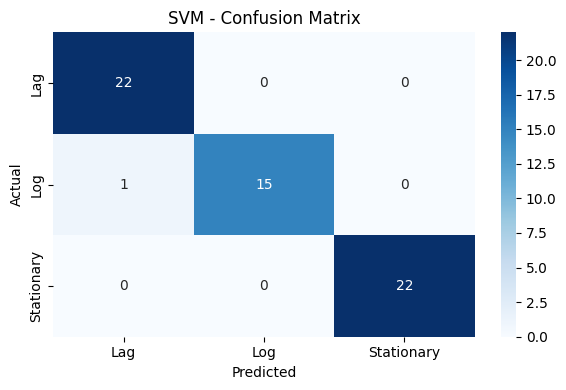

<ipython-input-39-1f9b9e1151f2>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_values, palette="viridis")
<ipython-input-39-1f9b9e1151f2>:44: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


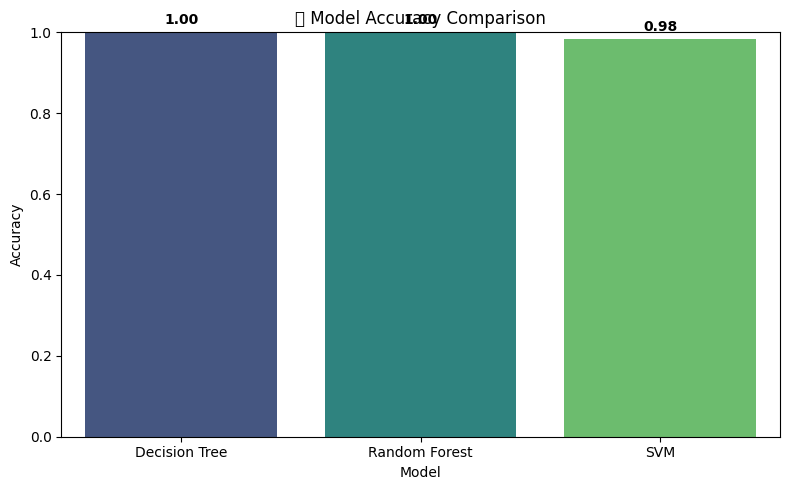

In [39]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

accuracies = {}

for name, model in models.items():
    print(f"\n🧪 Model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    accuracies[name] = acc

    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

sns.barplot(x=model_names, y=accuracy_values, palette="viridis")
plt.ylim(0, 1)
plt.title("📊 Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

This is for Proper visual in UI UX

In [11]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00


In [53]:
code='''import streamlit as st
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("bioprocess_classification_data_300.csv")

# Encode phase labels
label_encoder = LabelEncoder()
y_phase = label_encoder.fit_transform(df["Phase"])

# Models
phase_model = RandomForestRegressor(random_state=42)
phase_model.fit(df[["Time", "Biomass", "Substrate", "Product"]], y_phase)

yield_model = RandomForestRegressor(random_state=42)
yield_model.fit(df[["Time", "Biomass", "Substrate"]], df["Product"])

# Streamlit UI
st.set_page_config(page_title="Bioprocess Simulator", layout="wide")
st.title("🧪 Enhanced Bioprocess Yield & Phase Simulator")

# Layout: Two columns
col1, col2 = st.columns([3, 2])

with col1:
    st.header("Input Parameters")
    time_input = st.slider("⏱️ Time (hrs)", float(df.Time.min()), float(df.Time.max()), step=0.5, value=10.0)
    biomass_input = st.slider("🧫 Biomass (g/L)", float(df.Biomass.min()), float(df.Biomass.max()), step=0.5, value=2.0)
    substrate_input = st.slider("🧃 Substrate (g/L)", float(df.Substrate.min()), float(df.Substrate.max()), step=0.5, value=3.0)

    st.markdown("---")
    st.header("Simulation Progress")

    progress = st.progress(0)
    status = st.empty()
    yields = []
    times = np.linspace(0.1, time_input, 30)

    for i, t in enumerate(times):
        simulated_input = np.array([[t, biomass_input, substrate_input]])
        predicted_yield = yield_model.predict(simulated_input)[0]
        yields.append(predicted_yield)
        progress.progress(int((i + 1) / len(times) * 100))
        status.text(f"Simulating... Time: {round(t, 2)} hr | Yield: {round(predicted_yield, 2)} g/L")
        time.sleep(0.05)

    final_yield = round(yields[-1], 2)
    final_input = np.array([[time_input, biomass_input, substrate_input, final_yield]])
    phase_index = int(phase_model.predict(final_input)[0])
    predicted_phase = label_encoder.inverse_transform([phase_index])[0]

    st.success(f"✅ Final Yield: {final_yield} g/L")
    st.info(f"📌 Predicted Phase: **{predicted_phase}**")

    # Plot Yield Over Time
    st.subheader("📈 Product Yield Over Time")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(times, yields, color='mediumseagreen', marker='o')
    ax.set_xlabel("Time (hrs)")
    ax.set_ylabel("Predicted Product Yield (g/L)")
    ax.set_title("Real-time Yield Simulation")
    st.pyplot(fig)

with col2:
    st.header("Fermentor Tank Animation")

    # Show fermentor tank GIF
    # (Make sure you have fermentor.gif in your directory or replace URL with your own)
    st.image("https://www.bjholves.com/uploads/allimg/230215/7-230215151UN58.gif", width=300)


    # Show phase with colored badge
    phase_colors = {
        "Lag": "orange",
        "Log": "green",
        "Stationary": "red"
    }
    color = phase_colors.get(predicted_phase, "gray")
    st.markdown(f'<h3 style="color:{color};">🟢 Phase: {predicted_phase}</h3>', unsafe_allow_html=True)

    # Show yield as a colored progress bar
    max_yield = df["Product"].max()
    fill_percent = min(final_yield / max_yield, 1.0)
    st.markdown(f"### Product Yield Level:")
    st.progress(fill_percent)

    st.caption("Fermentor tank animation from GIF — reflects live process visually")'''

with open('app.py', 'w') as f:
    f.write(code)




In [54]:
!wget -q -O - ipv4.icanhazip.com

35.237.48.36


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.48.36:8501

⠧⠇your url is: https://eighty-news-itch.loca.lt
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
